# 🔍 Scanner de Cointégration v2 — Paires logiques uniquement
- Fenêtre réduite à 90 jours pour éviter les faux positifs de tendance
- Univers restreint aux paires avec logique économique

In [9]:
import ccxt
import pandas as pd
import numpy as np
from itertools import combinations
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1. Univers — paires avec logique économique uniquement

In [10]:
# Paires candidates avec sens économique réel
# On teste intra-catégorie + cross logiques (DeFi vs L1, L2 vs ETH, etc.)
CANDIDATE_PAIRS = [
    # DeFi intra
    ('AAVE/USDT', 'UNI/USDT'),
    ('AAVE/USDT', 'COMP/USDT'),
    ('AAVE/USDT', 'MKR/USDT'),
    ('AAVE/USDT', 'LDO/USDT'),
    ('AAVE/USDT', 'SNX/USDT'),
    ('AAVE/USDT', 'CRV/USDT'),
    ('UNI/USDT',  'COMP/USDT'),
    ('UNI/USDT',  'LDO/USDT'),
    ('UNI/USDT',  'SNX/USDT'),
    ('UNI/USDT',  'CRV/USDT'),
    ('LDO/USDT',  'CRV/USDT'),
    ('LDO/USDT',  'SNX/USDT'),
    ('MKR/USDT',  'COMP/USDT'),

    # DeFi vs ETH (sous-jacent naturel)
    ('AAVE/USDT', 'ETH/USDT'),
    ('UNI/USDT',  'ETH/USDT'),
    ('LDO/USDT',  'ETH/USDT'),
    ('CRV/USDT',  'ETH/USDT'),
    ('SNX/USDT',  'ETH/USDT'),
    ('MKR/USDT',  'ETH/USDT'),
    ('COMP/USDT', 'ETH/USDT'),

    # L2 intra (même technologie)
    ('ARB/USDT',  'OP/USDT'),
    ('ARB/USDT',  'MATIC/USDT'),
    ('OP/USDT',   'MATIC/USDT'),

    # L2 vs ETH
    ('ARB/USDT',  'ETH/USDT'),
    ('OP/USDT',   'ETH/USDT'),
    ('MATIC/USDT','ETH/USDT'),

    # L1 intra
    ('SOL/USDT',  'AVAX/USDT'),
    ('SOL/USDT',  'NEAR/USDT'),
    ('SOL/USDT',  'ATOM/USDT'),
    ('AVAX/USDT', 'NEAR/USDT'),
    ('AVAX/USDT', 'ATOM/USDT'),

    # L1 vs ETH
    ('SOL/USDT',  'ETH/USDT'),
    ('AVAX/USDT', 'ETH/USDT'),
    ('NEAR/USDT', 'ETH/USDT'),

    # DeFi vs L1 (corrélation sectorielle)
    ('AAVE/USDT', 'SOL/USDT'),
    ('AAVE/USDT', 'AVAX/USDT'),
    ('UNI/USDT',  'SOL/USDT'),
    ('LDO/USDT',  'SOL/USDT'),

    # Oracle
    ('LINK/USDT', 'ETH/USDT'),
    ('LINK/USDT', 'AAVE/USDT'),
    ('LINK/USDT', 'UNI/USDT'),

    # BTC paires
    ('BTC/USDT',  'ETH/USDT'),
    ('BTC/USDT',  'SOL/USDT'),
    ('BTC/USDT',  'AAVE/USDT'),
    ('BTC/USDT',  'LTC/USDT'),
]

ALL_SYMBOLS = list(set([s for pair in CANDIDATE_PAIRS for s in pair]))
print(f'Symboles à télécharger : {len(ALL_SYMBOLS)}')
print(f'Paires à tester        : {len(CANDIDATE_PAIRS)}')

Symboles à télécharger : 18
Paires à tester        : 45


## 2. Téléchargement — 90 jours

In [11]:
DAYS = 90  # Réduit à 90j pour éviter les faux positifs de tendance longue

def fetch_close(symbol, timeframe='15m', days=90):
    exchange = ccxt.binance({'enableRateLimit': True})
    since = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)
    all_ohlcv = []
    while True:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
            if not ohlcv:
                break
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1
            if ohlcv[-1][0] >= int(datetime.now().timestamp() * 1000) - (15 * 60 * 1000):
                break
        except Exception as e:
            print(f'⚠️ {symbol} : {e}')
            break
    if not all_ohlcv:
        return None
    df = pd.DataFrame(all_ohlcv, columns=['timestamp','open','high','low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.set_index('timestamp')[['close']]
    df = df[~df.index.duplicated(keep='first')]
    df.columns = [symbol]
    return df

print(f'📥 Téléchargement {DAYS}j de données 15m...')
prices = {}
failed = []

for sym in ALL_SYMBOLS:
    df = fetch_close(sym, days=DAYS)
    if df is not None and len(df) > 2000:
        prices[sym] = df
        print(f'  ✅ {sym:<15} — {len(df)} bougies')
    else:
        failed.append(sym)
        print(f'  ❌ {sym:<15} — indisponible')

print(f'\n✅ {len(prices)} symboles | ❌ échoués : {failed}')

📥 Téléchargement 90j de données 15m...
  ✅ LDO/USDT        — 8640 bougies
  ✅ NEAR/USDT       — 8640 bougies
  ✅ AAVE/USDT       — 8640 bougies
  ✅ ARB/USDT        — 8640 bougies
  ✅ ATOM/USDT       — 8640 bougies
  ✅ CRV/USDT        — 8640 bougies
  ✅ SOL/USDT        — 8640 bougies
  ✅ AVAX/USDT       — 8640 bougies
  ✅ UNI/USDT        — 8640 bougies
  ❌ MKR/USDT        — indisponible
  ✅ LINK/USDT       — 8640 bougies
  ✅ ETH/USDT        — 8640 bougies
  ✅ OP/USDT         — 8640 bougies
  ✅ COMP/USDT       — 8640 bougies
  ✅ LTC/USDT        — 8640 bougies
  ✅ SNX/USDT        — 8640 bougies
  ✅ BTC/USDT        — 8640 bougies
  ❌ MATIC/USDT      — indisponible

✅ 16 symboles | ❌ échoués : ['MKR/USDT', 'MATIC/USDT']


## 3. Scanner

In [12]:
def compute_hurst(series, max_lag=100):
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

def compute_half_life(spread):
    lag   = spread.shift(1).dropna()
    delta = spread.diff().dropna()
    lag, delta = lag.align(delta, join='inner')
    reg = OLS(delta, add_constant(lag)).fit()
    if reg.params[0] >= 0:
        return np.inf
    return -np.log(2) / reg.params[0]

def compute_zscore_stats(spread, window=200):
    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
    z = z.dropna()
    crossings = ((z.shift(1) * z) < 0).sum()
    amplitude = z[(z > 2) | (z < -2)].abs().mean()
    return crossings, amplitude

def analyze_pair(sym1, sym2, prices, window=200):
    if sym1 not in prices or sym2 not in prices:
        return None
    df = pd.concat([prices[sym1], prices[sym2]], axis=1).dropna()
    if len(df) < window * 2:
        return None

    split = int(len(df) * 0.8)
    train = df.iloc[:split]

    _, pvalue, _ = coint(train[sym1], train[sym2])
    if pvalue > 0.05:
        return None

    # Rolling OLS
    rolling_cov = df[sym1].rolling(window).cov(df[sym2])
    rolling_var = df[sym2].rolling(window).var()
    ratio  = rolling_cov / rolling_var
    spread = (df[sym1] - ratio * df[sym2]).dropna()

    adf_pvalue       = adfuller(spread.iloc[split:])[1]
    hurst            = compute_hurst(spread.values)
    half_life        = compute_half_life(spread)
    crossings, ampl  = compute_zscore_stats(spread)

    return {
        'pair'        : f'{sym1} / {sym2}',
        'coint_pvalue': round(pvalue, 5),
        'adf_oos'     : round(adf_pvalue, 5),
        'hurst'       : round(hurst, 3),
        'half_life'   : round(half_life, 1),
        'zero_cross'  : int(crossings),
        'amplitude'   : round(ampl, 3) if not np.isnan(ampl) else 0,
        'n_candles'   : len(df),
    }

print('🔬 Scan en cours...')
results = []
for s1, s2 in CANDIDATE_PAIRS:
    res = analyze_pair(s1, s2, prices)
    status = f"✅ {res['coint_pvalue']:.4f} | Hurst={res['hurst']} | HL={res['half_life']}" if res else '❌'
    print(f'  {s1:<15} / {s2:<15} → {status}')
    if res:
        results.append(res)

df_results = pd.DataFrame(results)
print(f'\n✅ {len(df_results)} paires cointégrées sur {len(CANDIDATE_PAIRS)} testées')

🔬 Scan en cours...
  AAVE/USDT       / UNI/USDT        → ❌
  AAVE/USDT       / COMP/USDT       → ❌
  AAVE/USDT       / MKR/USDT        → ❌
  AAVE/USDT       / LDO/USDT        → ❌
  AAVE/USDT       / SNX/USDT        → ❌
  AAVE/USDT       / CRV/USDT        → ❌
  UNI/USDT        / COMP/USDT       → ❌
  UNI/USDT        / LDO/USDT        → ❌
  UNI/USDT        / SNX/USDT        → ❌
  UNI/USDT        / CRV/USDT        → ❌
  LDO/USDT        / CRV/USDT        → ❌
  LDO/USDT        / SNX/USDT        → ❌
  MKR/USDT        / COMP/USDT       → ❌
  AAVE/USDT       / ETH/USDT        → ✅ 0.0281 | Hurst=0.756 | HL=1920.7
  UNI/USDT        / ETH/USDT        → ❌
  LDO/USDT        / ETH/USDT        → ✅ 0.0453 | Hurst=0.71 | HL=1617.3
  CRV/USDT        / ETH/USDT        → ❌
  SNX/USDT        / ETH/USDT        → ❌
  MKR/USDT        / ETH/USDT        → ❌
  COMP/USDT       / ETH/USDT        → ❌
  ARB/USDT        / OP/USDT         → ❌
  ARB/USDT        / MATIC/USDT      → ❌
  OP/USDT         / MATIC/USDT      

## 4. Scoring et classement

In [13]:
def score_pair(row):
    score = 0
    # Hurst (30 pts)
    if   row['hurst'] < 0.3: score += 30
    elif row['hurst'] < 0.4: score += 20
    elif row['hurst'] < 0.5: score += 10
    # ADF OOS (25 pts)
    if   row['adf_oos'] < 0.01: score += 25
    elif row['adf_oos'] < 0.05: score += 15
    # Half-life (20 pts) — idéal 10-50 bougies (2.5h-12.5h en 15m)
    hl = row['half_life']
    if   10 <= hl <= 50:  score += 20
    elif  5 <= hl <= 100: score += 10
    # Zero-crossings (15 pts)
    if   row['zero_cross'] > 200: score += 15
    elif row['zero_cross'] > 100: score += 8
    # Amplitude (10 pts)
    if   row['amplitude'] > 2.5: score += 10
    elif row['amplitude'] > 2.0: score += 5
    return score

if len(df_results) > 0:
    df_results['score'] = df_results.apply(score_pair, axis=1)
    df_results = df_results.sort_values('score', ascending=False).reset_index(drop=True)

    # Affichage complet sans filtre strict sur Hurst (pour voir même les paires borderline)
    print('🏆 TOUTES LES PAIRES COINTÉGRÉES — triées par score')
    print('=' * 105)
    pd.set_option('display.max_colwidth', 35)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(df_results[['pair','score','coint_pvalue','adf_oos','hurst','half_life','zero_cross','amplitude']].to_string())
else:
    print('❌ Aucune paire cointégrée trouvée — essaie d\'assouplir les critères')

🏆 TOUTES LES PAIRES COINTÉGRÉES — triées par score
                   pair  score  coint_pvalue  adf_oos  hurst  half_life  zero_cross  amplitude
0  AAVE/USDT / ETH/USDT     25        0.0281   0.0400 0.7560  1920.7000          58     2.7460
1   LDO/USDT / ETH/USDT     25        0.0453   0.0317 0.7100  1617.3000          92     2.5820
2  LINK/USDT / UNI/USDT     10        0.0086   0.1482 0.6970  1508.8000          63     2.5930


## 5. Analyse détaillée du Top 5

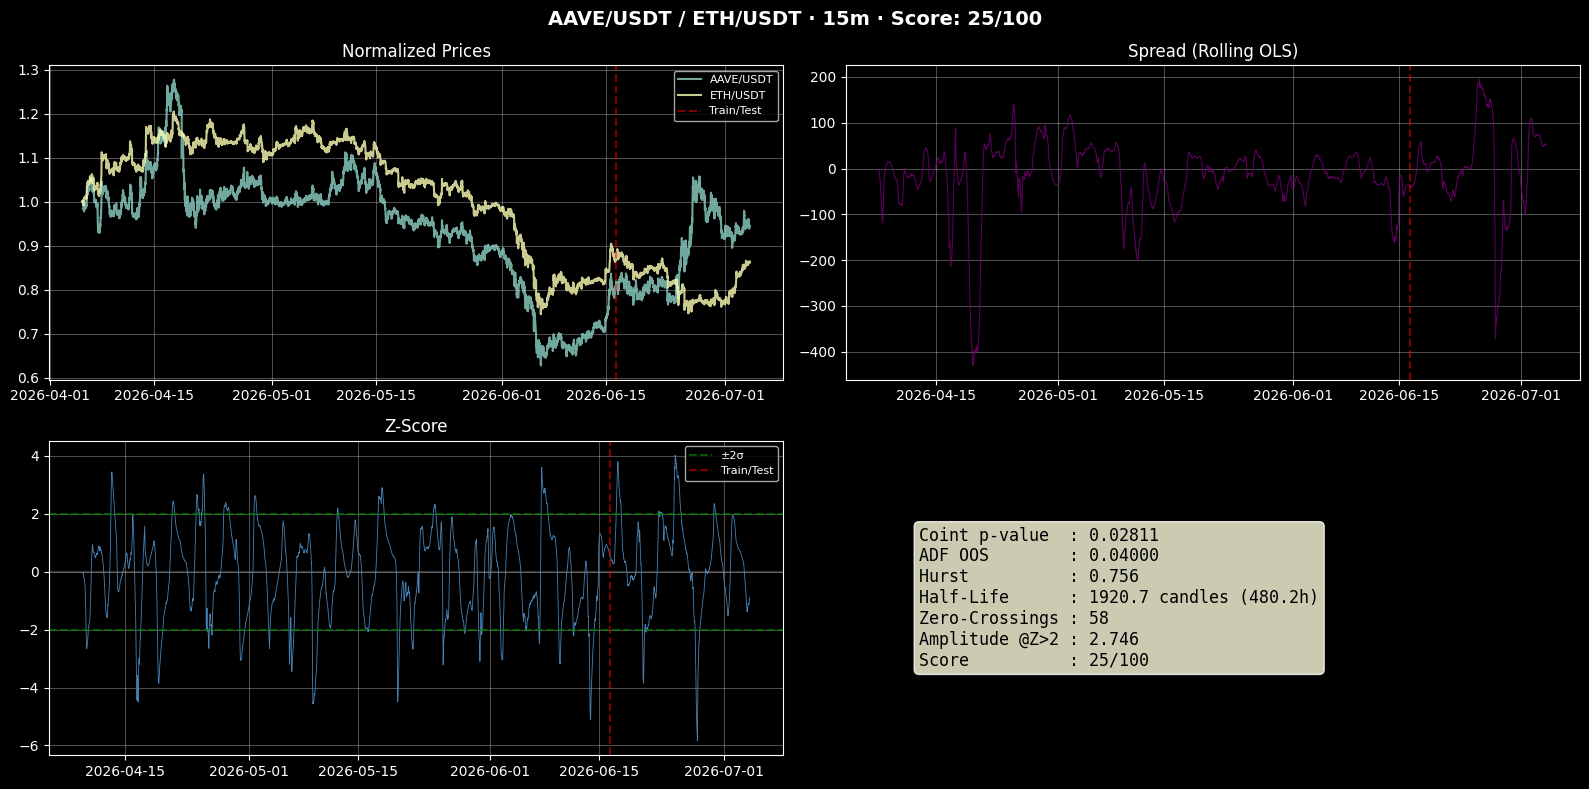

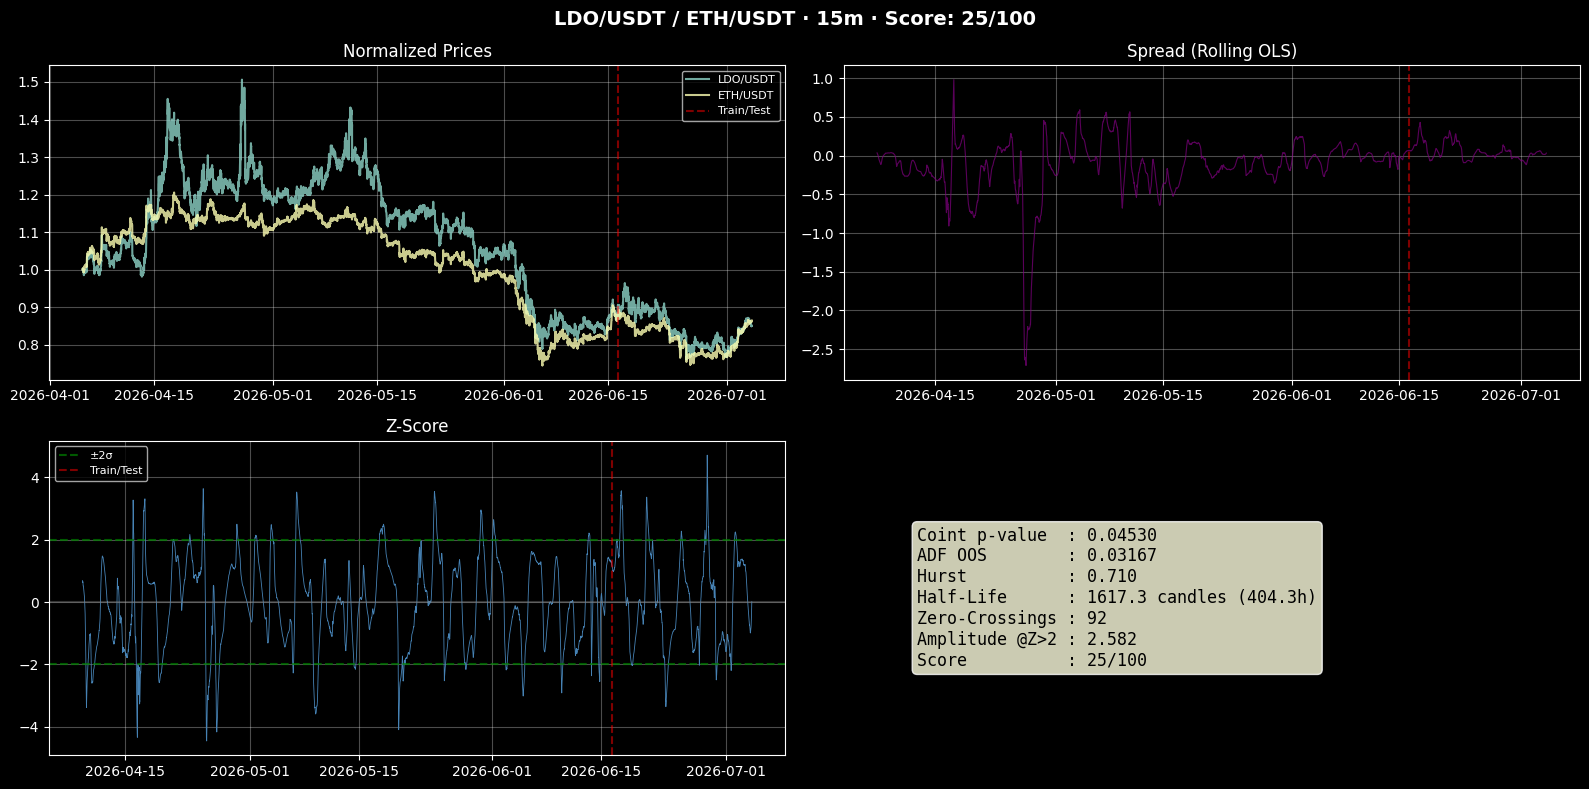

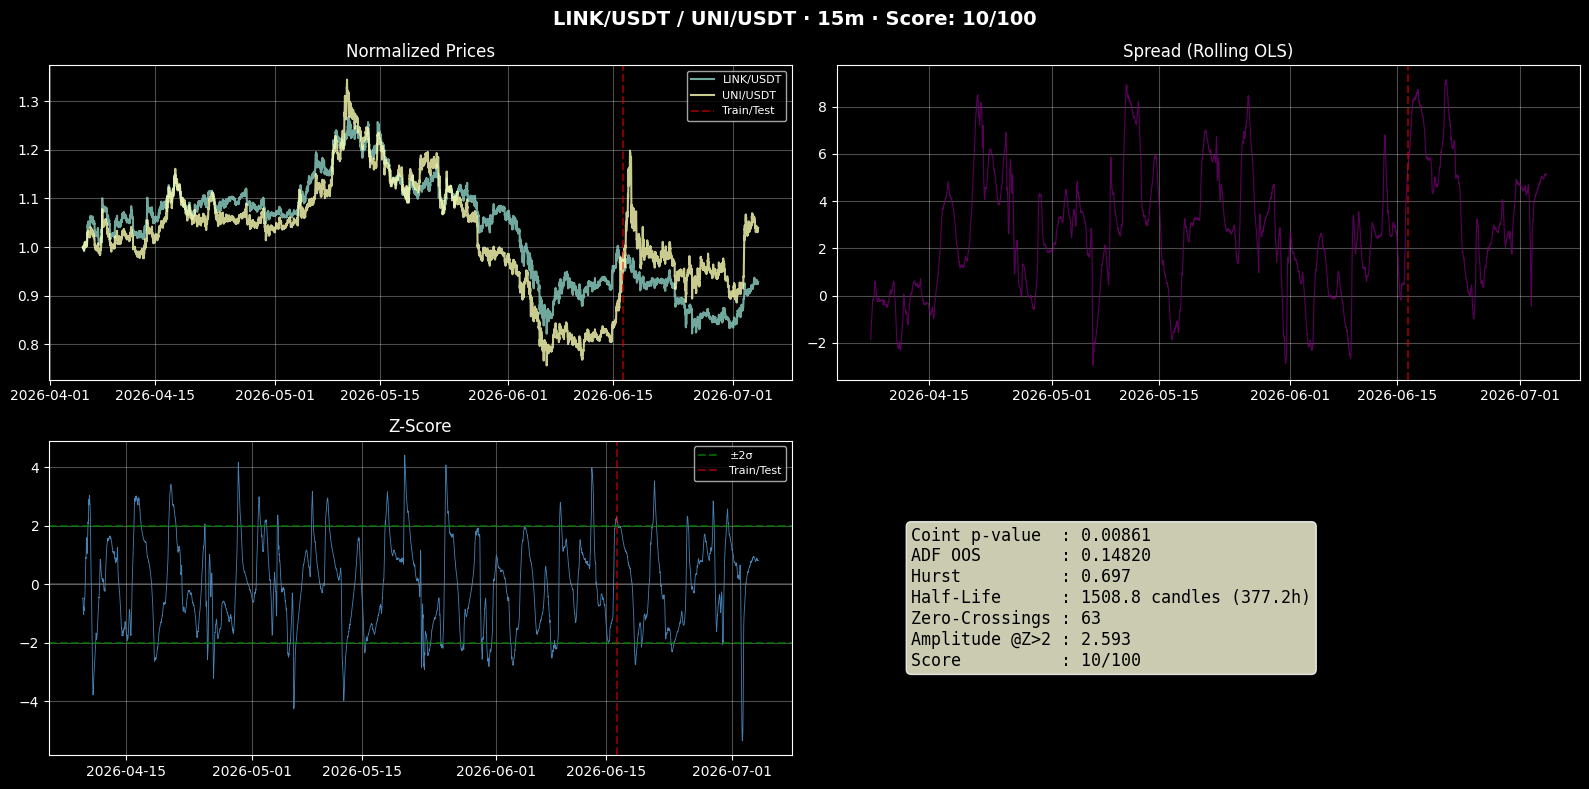

In [14]:
plt.style.use('dark_background')

top5 = df_results.head(5)

for idx, (_, row) in enumerate(top5.iterrows()):
    parts = row['pair'].split(' / ')
    sym1, sym2 = parts[0].strip(), parts[1].strip()

    if sym1 not in prices or sym2 not in prices:
        continue

    df = pd.concat([prices[sym1], prices[sym2]], axis=1).dropna()
    split = int(len(df) * 0.8)

    rolling_cov = df[sym1].rolling(200).cov(df[sym2])
    rolling_var = df[sym2].rolling(200).var()
    ratio  = rolling_cov / rolling_var
    spread = df[sym1] - ratio * df[sym2]
    zscore = (spread - spread.rolling(200).mean()) / spread.rolling(200).std()
    zscore = zscore.dropna()

    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, 2, figure=fig)

    ax1 = fig.add_subplot(gs[0, 0])
    norm1 = df[sym1] / df[sym1].iloc[0]
    norm2 = df[sym2] / df[sym2].iloc[0]
    ax1.plot(norm1.index, norm1, label=sym1, alpha=0.8)
    ax1.plot(norm2.index, norm2, label=sym2, alpha=0.8)
    ax1.axvline(df.index[split], color='red', linestyle='--', alpha=0.5, label='Train/Test')
    ax1.set_title('Normalized Prices')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(spread.index, spread, color='purple', alpha=0.7, linewidth=0.8)
    ax2.axvline(df.index[split], color='red', linestyle='--', alpha=0.5)
    ax2.set_title('Spread (Rolling OLS)')
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(zscore.index, zscore, color='steelblue', linewidth=0.6)
    ax3.axhline( 2, color='green', linestyle='--', alpha=0.7, label='±2σ')
    ax3.axhline(-2, color='green', linestyle='--', alpha=0.7)
    ax3.axhline( 0, color='gray',  linestyle='-',  alpha=0.4)
    ax3.axvline(df.index[split], color='red', linestyle='--', alpha=0.5, label='Train/Test')
    ax3.set_title('Z-Score')
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    txt = (
        f"Coint p-value  : {row['coint_pvalue']:.5f}\n"
        f"ADF OOS        : {row['adf_oos']:.5f}\n"
        f"Hurst          : {row['hurst']:.3f}\n"
        f"Half-Life      : {row['half_life']:.1f} candles ({row['half_life']*15/60:.1f}h)\n"
        f"Zero-Crossings : {row['zero_cross']}\n"
        f"Amplitude @Z>2 : {row['amplitude']:.3f}\n"
        f"Score          : {row['score']}/100"
    )
    ax4.text(0.1, 0.5, txt, transform=ax4.transAxes, fontsize=12,
             verticalalignment='center', fontfamily='monospace', color='black',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    fig.suptitle(f"{sym1} / {sym2} · 15m · Score: {row['score']}/100", fontsize=14, fontweight='bold')

    if idx == 0:
        plt.savefig('cointegration_notebook.png', dpi=150, bbox_inches='tight', facecolor='#0a0d12')

    plt.tight_layout()
    plt.show()
    print()

## 6. Export

In [15]:
df_results.to_csv('scan_v2_results.csv', index=False)
print(f'💾 scan_v2_results.csv — {len(df_results)} paires cointégrées')

💾 scan_v2_results.csv — 3 paires cointégrées
